<a href="https://colab.research.google.com/github/catherineollermann-dot/energy-intelligence-platform/blob/main/AWS_Energy_Analytics_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ☁️ Cloud-Based Energy Analytics Pipeline on AWS

## End-to-End Big Data Analytics using Apache Spark and Machine Learning

### Author
Catherine Gayer Ollermann

### Institution
Avila University

---

## Project Overview

This notebook demonstrates a complete cloud-based data analytics pipeline using the State Energy Data System (SEDS) dataset.

The workflow includes:

- Data ingestion
- Data preprocessing
- Feature engineering
- Machine Learning with Spark MLlib
- Model evaluation
- Data visualization

The project demonstrates how Apache Spark can be used to process large-scale energy datasets while supporting scalable machine learning workflows.

In [29]:
!pip install pyspark

In [30]:
# ==========================================================
# Import Libraries
# ==========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql.functions import *

from pyspark.ml.feature import VectorAssembler

from pyspark.ml.regression import (
    LinearRegression,
    DecisionTreeRegressor,
    RandomForestRegressor
)

from pyspark.ml.evaluation import RegressionEvaluator

# Create Spark Session

Apache Spark is used as the distributed computing engine responsible for loading, processing, transforming, and analyzing the energy dataset.

In [31]:
# ==========================================================
# Create Spark Session
# ==========================================================

spark = SparkSession.builder \
    .appName("AWS Energy Analytics Pipeline") \
    .getOrCreate()

print("Spark Session Created Successfully!")

Spark Session Created Successfully!


# Load Dataset

The State Energy Data System (SEDS) dataset is loaded into a Spark DataFrame for distributed processing.

In [52]:
from google.colab import files

uploaded = files.upload()

Saving Complete_SEDS (2).csv to Complete_SEDS (2).csv


In [53]:
# ==========================================================
# Load Dataset
# ==========================================================

df = spark.read.csv(
    "Complete_SEDS.csv",
    header=True,
    inferSchema=True
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


# Data Exploration

Before preprocessing the dataset, we inspect its structure, dimensions, data types, and sample records to better understand the available information.

In [54]:
# ==========================================================
# Dataset Dimensions
# ==========================================================

rows = df.count()
columns = len(df.columns)

print(f"Number of rows: {rows:,}")
print(f"Number of columns: {columns}")

Number of rows: 1,048,575
Number of columns: 5


# Dataset Schema

The schema inspection provides information about each column, its data type, and how Spark interprets the dataset.

In [55]:
# ==========================================================
# Dataset Schema
# ==========================================================

df.printSchema()

root
 |-- Data_Status: double (nullable = true)
 |-- MSN: string (nullable = true)
 |-- StateCode: string (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Data: double (nullable = true)



# Sample Records

The first records of the dataset provide an overview of its structure and help validate that the data has been loaded correctly.

In [56]:
# ==========================================================
# Display Sample Records
# ==========================================================

df.show(10, truncate=False)

+-----------+-----+---------+----+----+
|Data_Status|MSN  |StateCode|Year|Data|
+-----------+-----+---------+----+----+
|2023.0     |ABICB|AK       |1960|0.0 |
|2023.0     |ABICB|AK       |1961|0.0 |
|2023.0     |ABICB|AK       |1962|0.0 |
|2023.0     |ABICB|AK       |1963|0.0 |
|2023.0     |ABICB|AK       |1964|0.0 |
|2023.0     |ABICB|AK       |1965|0.0 |
|2023.0     |ABICB|AK       |1966|0.0 |
|2023.0     |ABICB|AK       |1967|0.0 |
|2023.0     |ABICB|AK       |1968|0.0 |
|2023.0     |ABICB|AK       |1969|0.0 |
+-----------+-----+---------+----+----+
only showing top 10 rows


# Dataset Overview

This section summarizes key characteristics of the dataset, including the number of unique states, energy indicators, and the available time period.

In [57]:
# ==========================================================
# Dataset Overview
# ==========================================================

print(f"Unique States: {df.select('StateCode').distinct().count()}")

print(f"Unique Energy Indicators (MSN): {df.select('MSN').distinct().count()}")

df.selectExpr(
    "min(Year) as First_Year",
    "max(Year) as Last_Year"
).show()

Unique States: 54
Unique Energy Indicators (MSN): 437
+----------+---------+
|First_Year|Last_Year|
+----------+---------+
|      1960|     2023|
+----------+---------+



# Missing Values Analysis

Before preprocessing, we check whether the dataset contains missing values that could affect data quality or machine learning performance.

In [58]:
# ==========================================================
# Missing Values Analysis
# ==========================================================

from pyspark.sql.functions import col, when, count

missing = df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
])

missing.show()

+-----------+---+---------+----+----+
|Data_Status|MSN|StateCode|Year|Data|
+-----------+---+---------+----+----+
|          0|  0|        0|   0|   0|
+-----------+---+---------+----+----+



# Descriptive Statistics

Before applying machine learning models, we examine the statistical properties of the numerical variables. This step helps identify data ranges, potential outliers, and the overall distribution of the dataset.

In [59]:
# ==========================================================
# Descriptive Statistics
# ==========================================================

df.describe().show()

+-------+-----------+-------+---------+------------------+-----------------+
|summary|Data_Status|    MSN|StateCode|              Year|             Data|
+-------+-----------+-------+---------+------------------+-----------------+
|  count|    1048575|1048575|  1048575|           1048575|          1048575|
|   mean|     2023.0|   NULL|     NULL|1994.1672813103498|38579.74754744002|
| stddev|        0.0|   NULL|     NULL|18.108430655600127|684631.5048038063|
|    min|     2023.0|  ABICB|       AK|              1960|        -756639.0|
|    max|     2023.0|  KSRCB|       X5|              2023|      8.5827701E7|
+-------+-----------+-------+---------+------------------+-----------------+



# Distribution by State

This section summarizes the number of records available for each state and territory included in the dataset.

In [60]:
# ==========================================================
# Records by State
# ==========================================================

state_counts = (
    df.groupBy("StateCode")
      .count()
      .orderBy("count", ascending=False)
)

state_counts.show(15)

+---------+-----+
|StateCode|count|
+---------+-----+
|       US|21703|
|       AZ|20189|
|       CA|20189|
|       AL|20189|
|       AK|20189|
|       AR|20189|
|       CO|20174|
|       SC|20125|
|       LA|20125|
|       MN|20125|
|       NJ|20125|
|       DC|20125|
|       OR|20125|
|       VA|20125|
|       RI|20125|
+---------+-----+
only showing top 15 rows


# Records by Year

This section summarizes the temporal coverage of the dataset.

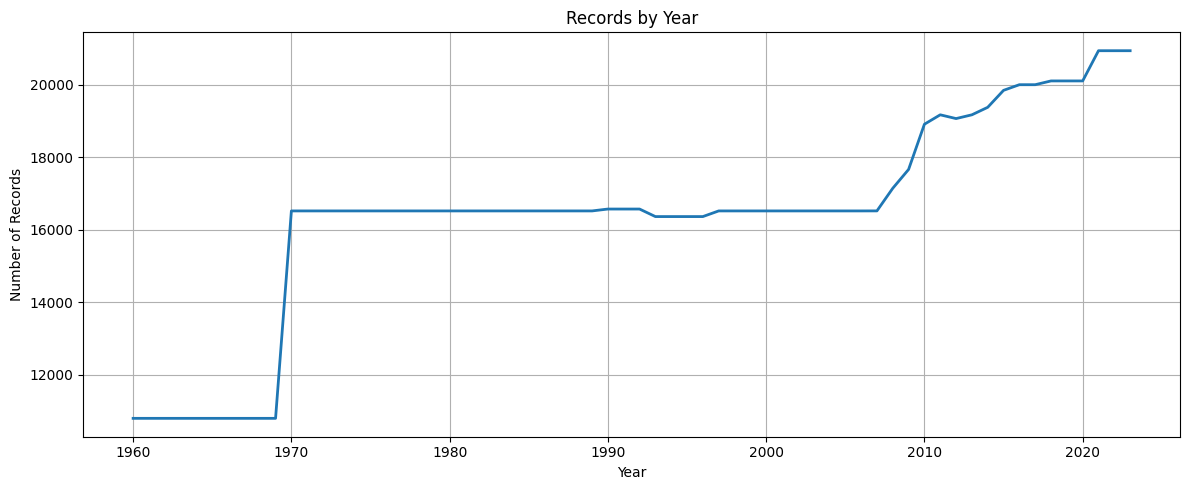

In [61]:
# ==========================================================
# Records by Year
# ==========================================================

year_counts = (
    df.groupBy("Year")
      .count()
      .orderBy("Year")
)

year_counts_pd = year_counts.toPandas()

plt.figure(figsize=(12,5))
plt.plot(year_counts_pd["Year"], year_counts_pd["count"], linewidth=2)

plt.title("Records by Year")
plt.xlabel("Year")
plt.ylabel("Number of Records")

plt.grid(True)

plt.tight_layout()
plt.show()

# Feature Engineering

Machine learning models require numerical feature vectors as input. The selected features are combined into a single feature vector using Spark MLlib's VectorAssembler.

In [62]:
# ==========================================================
# Feature Engineering
# ==========================================================

from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=["Year", "Data_Status"],
    outputCol="features"
)

data = assembler.transform(df)

data.select("features", "Data").show(5, truncate=False)

+---------------+----+
|features       |Data|
+---------------+----+
|[1960.0,2023.0]|0.0 |
|[1961.0,2023.0]|0.0 |
|[1962.0,2023.0]|0.0 |
|[1963.0,2023.0]|0.0 |
|[1964.0,2023.0]|0.0 |
+---------------+----+
only showing top 5 rows


In [63]:
from pyspark.sql.functions import min, max

data.select(
    min("Data").alias("Min"),
    max("Data").alias("Max")
).show()

+---------+-----------+
|      Min|        Max|
+---------+-----------+
|-756639.0|8.5827701E7|
+---------+-----------+



In [64]:
print(data.columns)

['Data_Status', 'MSN', 'StateCode', 'Year', 'Data', 'features']


# Train-Test Split

The dataset is divided into training and testing subsets to evaluate the predictive performance of the machine learning models.

In [65]:
# ==========================================================
# Train-Test Split
# ==========================================================

train_data, test_data = data.randomSplit([0.8, 0.2], seed=42)

print(f"Training records: {train_data.count():,}")
print(f"Testing records: {test_data.count():,}")

Training records: 838,889
Testing records: 209,686


# Linear Regression

A Linear Regression model is trained using Spark MLlib to establish a baseline for predicting energy values.

In [66]:
# ==========================================================
# Linear Regression
# ==========================================================

from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

lr = LinearRegression(
    featuresCol="features",
    labelCol="Data"
)

lr_model = lr.fit(train_data)

lr_predictions = lr_model.transform(test_data)

evaluator = RegressionEvaluator(
    labelCol="Data",
    predictionCol="prediction",
    metricName="rmse"
)

lr_rmse = evaluator.evaluate(lr_predictions)

print(f"Linear Regression RMSE: {lr_rmse:.2f}")

Linear Regression RMSE: 696639.04


In [67]:
# ==========================================================
# Dataset Selection
# ==========================================================

from pyspark.sql.functions import col

ml_df = df.filter(
    (col("StateCode") == "AK") &
    (col("MSN") == "MGACB")
)

print("Rows:", ml_df.count())

ml_df.show(5)

Rows: 0
+-----------+---+---------+----+----+
|Data_Status|MSN|StateCode|Year|Data|
+-----------+---+---------+----+----+
+-----------+---+---------+----+----+



In [68]:
# Todos os códigos MSN de Alaska

from pyspark.sql.functions import col

df.filter(col("StateCode") == "AK") \
  .select("MSN") \
  .distinct() \
  .orderBy("MSN") \
  .show(500, truncate=False)

+-----+
|MSN  |
+-----+
|ABICB|
|ABICP|
|ARICB|
|ARICD|
|ARICP|
|ARICV|
|ARTCB|
|ARTCD|
|ARTCP|
|ARTCV|
|ARTXB|
|ARTXD|
|ARTXP|
|ARTXV|
|AVACB|
|AVACD|
|AVACP|
|AVACV|
|AVTCB|
|AVTCD|
|AVTCP|
|AVTCV|
|AVTXB|
|AVTXD|
|AVTXP|
|AVTXV|
|B1ABB|
|B1ABP|
|B1ACB|
|B1ACP|
|B1AUB|
|B1AUP|
|B1PRB|
|B1PRP|
|B1RIB|
|B1RIP|
|B1TCB|
|B1TCP|
|BDABB|
|BDABP|
|BDACB|
|BDACP|
|BDAUB|
|BDAUP|
|BDCBB|
|BDCBP|
|BDCCB|
|BDCCP|
|BDCUB|
|BDCUP|
|BDEIB|
|BDEIK|
|BDEIP|
|BDEUB|
|BDEUP|
|BDFDB|
|BDLCB|
|BDPRP|
|BDRBB|
|BDRBP|
|BDRCB|
|BDRCP|
|BDRIB|
|BDRIP|
|BDRUB|
|BDRUP|
|BDSAB|
|BDSAP|
|BDSUB|
|BDSUP|
|BDTCB|
|BDTCK|
|BDTCP|
|BDTXB|
|BDTXP|
|BDXUB|
|BDXUP|
|BFLCB|
|BFPRB|
|BFPRP|
|BFTCB|
|BMCAS|
|BMTCB|
|BOPRB|
|BOPRP|
|BQICB|
|BQICP|
|BQTCB|
|BQTCP|
|BTCAS|
|BTGBP|
|BTVHN|
|BTVHP|
|BXSUB|
|BXSUP|
|BYICB|
|BYICP|
|BYTCB|
|BYTCP|
|CDEGR|
|CDTCR|
|CDTPR|
|CLACB|
|CLACD|
|CLACE|
|CLACK|
|CLACP|
|CLACV|
|CLCAS|
|CLCCB|
|CLCCD|
|CLCCE|
|CLCCP|
|CLCCV|
|CLEIB|
|CLEID|
|CLEIE|
|CLEIK|
|CLEIP|
|CLEIV|
|CLGBP|
|CLHCK|


In [69]:
df.filter(col("MSN").contains("MG")).select("MSN").distinct().show(100, truncate=False)

+---+
|MSN|
+---+
+---+



In [70]:
df.filter(col("MSN").contains("GA")).select("MSN").distinct().show(100, truncate=False)

+---+
|MSN|
+---+
+---+



In [71]:
from pyspark.sql.functions import col

df.filter(col("StateCode") == "AK") \
  .select("MSN") \
  .distinct() \
  .orderBy("MSN") \
  .show(500, truncate=False)

+-----+
|MSN  |
+-----+
|ABICB|
|ABICP|
|ARICB|
|ARICD|
|ARICP|
|ARICV|
|ARTCB|
|ARTCD|
|ARTCP|
|ARTCV|
|ARTXB|
|ARTXD|
|ARTXP|
|ARTXV|
|AVACB|
|AVACD|
|AVACP|
|AVACV|
|AVTCB|
|AVTCD|
|AVTCP|
|AVTCV|
|AVTXB|
|AVTXD|
|AVTXP|
|AVTXV|
|B1ABB|
|B1ABP|
|B1ACB|
|B1ACP|
|B1AUB|
|B1AUP|
|B1PRB|
|B1PRP|
|B1RIB|
|B1RIP|
|B1TCB|
|B1TCP|
|BDABB|
|BDABP|
|BDACB|
|BDACP|
|BDAUB|
|BDAUP|
|BDCBB|
|BDCBP|
|BDCCB|
|BDCCP|
|BDCUB|
|BDCUP|
|BDEIB|
|BDEIK|
|BDEIP|
|BDEUB|
|BDEUP|
|BDFDB|
|BDLCB|
|BDPRP|
|BDRBB|
|BDRBP|
|BDRCB|
|BDRCP|
|BDRIB|
|BDRIP|
|BDRUB|
|BDRUP|
|BDSAB|
|BDSAP|
|BDSUB|
|BDSUP|
|BDTCB|
|BDTCK|
|BDTCP|
|BDTXB|
|BDTXP|
|BDXUB|
|BDXUP|
|BFLCB|
|BFPRB|
|BFPRP|
|BFTCB|
|BMCAS|
|BMTCB|
|BOPRB|
|BOPRP|
|BQICB|
|BQICP|
|BQTCB|
|BQTCP|
|BTCAS|
|BTGBP|
|BTVHN|
|BTVHP|
|BXSUB|
|BXSUP|
|BYICB|
|BYICP|
|BYTCB|
|BYTCP|
|CDEGR|
|CDTCR|
|CDTPR|
|CLACB|
|CLACD|
|CLACE|
|CLACK|
|CLACP|
|CLACV|
|CLCAS|
|CLCCB|
|CLCCD|
|CLCCE|
|CLCCP|
|CLCCV|
|CLEIB|
|CLEID|
|CLEIE|
|CLEIK|
|CLEIP|
|CLEIV|
|CLGBP|
|CLHCK|


In [72]:
# Mostrar os primeiros registros
df.select("MSN", "Description").distinct().show(100, truncate=False)

{"ts": "2026-07-24 23:39:33.990", "level": "ERROR", "logger": "DataFrameQueryContextLogger", "msg": "[UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `Description` cannot be resolved. Did you mean one of the following? [`Data`, `Year`, `Data_Status`, `MSN`, `StateCode`]. SQLSTATE: 42703", "context": {"file": "jdk.internal.reflect.GeneratedMethodAccessor54.invoke(Unknown Source)", "line": "", "fragment": "col", "errorClass": "UNRESOLVED_COLUMN.WITH_SUGGESTION"}, "exception": {"class": "Py4JJavaError", "msg": "An error occurred while calling o725.select.\n: org.apache.spark.sql.AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `Description` cannot be resolved. Did you mean one of the following? [`Data`, `Year`, `Data_Status`, `MSN`, `StateCode`]. SQLSTATE: 42703;\n'Project [MSN#1458, 'Description]\n+- Relation [Data_Status#1457,MSN#1458,StateCode#1459,Year#1460,Data#1461] csv\n\n\tat org.apach

AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `Description` cannot be resolved. Did you mean one of the following? [`Data`, `Year`, `Data_Status`, `MSN`, `StateCode`]. SQLSTATE: 42703;
'Project [MSN#1458, 'Description]
+- Relation [Data_Status#1457,MSN#1458,StateCode#1459,Year#1460,Data#1461] csv


In [73]:
df.printSchema()

root
 |-- Data_Status: double (nullable = true)
 |-- MSN: string (nullable = true)
 |-- StateCode: string (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Data: double (nullable = true)



In [74]:
msns = (
    df.select("MSN")
      .distinct()
      .orderBy("MSN")
      .toPandas()
)

msns

,MSN
0,ABICB
1,ABICP
2,ARICB
3,ARICD
4,ARICP
...,...
432,KSICB
433,KSICD
434,KSICP
435,KSICV


In [75]:
df.filter(df.StateCode == "AK").show(20, truncate=False)

+-----------+-----+---------+----+----+
|Data_Status|MSN  |StateCode|Year|Data|
+-----------+-----+---------+----+----+
|2023.0     |ABICB|AK       |1960|0.0 |
|2023.0     |ABICB|AK       |1961|0.0 |
|2023.0     |ABICB|AK       |1962|0.0 |
|2023.0     |ABICB|AK       |1963|0.0 |
|2023.0     |ABICB|AK       |1964|0.0 |
|2023.0     |ABICB|AK       |1965|0.0 |
|2023.0     |ABICB|AK       |1966|0.0 |
|2023.0     |ABICB|AK       |1967|0.0 |
|2023.0     |ABICB|AK       |1968|0.0 |
|2023.0     |ABICB|AK       |1969|0.0 |
|2023.0     |ABICB|AK       |1970|0.0 |
|2023.0     |ABICB|AK       |1971|0.0 |
|2023.0     |ABICB|AK       |1972|0.0 |
|2023.0     |ABICB|AK       |1973|0.0 |
|2023.0     |ABICB|AK       |1974|0.0 |
|2023.0     |ABICB|AK       |1975|0.0 |
|2023.0     |ABICB|AK       |1976|0.0 |
|2023.0     |ABICB|AK       |1977|0.0 |
|2023.0     |ABICB|AK       |1978|0.0 |
|2023.0     |ABICB|AK       |1979|0.0 |
+-----------+-----+---------+----+----+
only showing top 20 rows


In [76]:
df.filter(df.MSN == "ABICB").show(20, truncate=False)

+-----------+-----+---------+----+----+
|Data_Status|MSN  |StateCode|Year|Data|
+-----------+-----+---------+----+----+
|2023.0     |ABICB|AK       |1960|0.0 |
|2023.0     |ABICB|AK       |1961|0.0 |
|2023.0     |ABICB|AK       |1962|0.0 |
|2023.0     |ABICB|AK       |1963|0.0 |
|2023.0     |ABICB|AK       |1964|0.0 |
|2023.0     |ABICB|AK       |1965|0.0 |
|2023.0     |ABICB|AK       |1966|0.0 |
|2023.0     |ABICB|AK       |1967|0.0 |
|2023.0     |ABICB|AK       |1968|0.0 |
|2023.0     |ABICB|AK       |1969|0.0 |
|2023.0     |ABICB|AK       |1970|0.0 |
|2023.0     |ABICB|AK       |1971|0.0 |
|2023.0     |ABICB|AK       |1972|0.0 |
|2023.0     |ABICB|AK       |1973|0.0 |
|2023.0     |ABICB|AK       |1974|0.0 |
|2023.0     |ABICB|AK       |1975|0.0 |
|2023.0     |ABICB|AK       |1976|0.0 |
|2023.0     |ABICB|AK       |1977|0.0 |
|2023.0     |ABICB|AK       |1978|0.0 |
|2023.0     |ABICB|AK       |1979|0.0 |
+-----------+-----+---------+----+----+
only showing top 20 rows


In [77]:
from pyspark.sql.functions import avg, stddev

stats = (
    df.groupBy("MSN")
      .agg(
          avg("Data").alias("mean"),
          stddev("Data").alias("std")
      )
      .orderBy(stats := "std", ascending=False)
)

stats.show(20, truncate=False)

+-----+------------------+------------------+
|MSN  |mean              |std               |
+-----+------------------+------------------+
|FFTCB|2746154.562800481 |9873964.515938578 |
|CLPRB|691054.7169471154 |2647552.431680288 |
|CLSCB|658414.0487891738 |2402618.46654909  |
|GDPRX|663136.2141025648 |2396425.386275438 |
|GDPRV|613976.298575498  |2306561.822636753 |
|CLTCB|622413.0303485577 |2291544.755008199 |
|CLEIB|508511.60516826925|1940960.5205519544|
|ESSCB|382218.9569088319 |1402247.6419006994|
|ESTCB|345966.2578125    |1319250.4042949567|
|ESTXB|345966.2578125    |1319250.4042949567|
|DFSCB|280762.6424501425 |1002426.8637207735|
|DATCB|264449.9272836539 |954882.969380864  |
|DFTCB|263789.21604567306|951919.0953432536 |
|DMTCB|262188.92848557694|945170.1857153912 |
|DFTXB|259730.34194711538|937755.1704591295 |
|DFASB|171302.4886039886 |646915.4369294601 |
|DAACB|151300.29086538462|599190.533630816  |
|DFACB|150656.36328125   |595603.166391344  |
|DMACB|149095.04627403847|587580.3

In [78]:
from pyspark.sql.functions import col

energy_df = (
    df.filter((col("MSN") == "FFTCB") & (col("StateCode") == "AK"))
      .select("Year", "Data")
      .orderBy("Year")
)

energy_df.show(70, truncate=False)

+----+--------+
|Year|Data    |
+----+--------+
|1960|54633.0 |
|1961|64860.0 |
|1962|71359.0 |
|1963|72995.0 |
|1964|76965.0 |
|1965|79263.0 |
|1966|94368.0 |
|1967|106715.0|
|1968|114046.0|
|1969|148176.0|
|1970|173203.0|
|1971|191869.0|
|1972|205703.0|
|1973|189120.0|
|1974|193159.0|
|1975|223564.0|
|1976|245447.0|
|1977|282041.0|
|1978|313201.0|
|1979|289041.0|
|1980|287424.0|
|1981|270444.0|
|1982|400312.0|
|1983|428036.0|
|1984|471737.0|
|1985|462646.0|
|1986|493544.0|
|1987|487208.0|
|1988|508637.0|
|1989|557850.0|
|1990|565722.0|
|1991|585301.0|
|1992|608935.0|
|1993|603057.0|
|1994|599447.0|
|1995|680916.0|
|1996|696830.0|
|1997|693152.0|
|1998|709565.0|
|1999|714721.0|
|2000|729682.0|
|2001|718294.0|
|2002|714637.0|
|2003|713860.0|
|2004|756139.0|
|2005|781788.0|
|2006|732971.0|
|2007|708937.0|
|2008|637369.0|
|2009|623900.0|
|2010|621526.0|
|2011|624242.0|
|2012|612759.0|
|2013|578747.0|
|2014|574204.0|
|2015|589945.0|
|2016|567977.0|
|2017|577418.0|
|2018|580080.0|
|2019|58

<Axes: title={'center': 'FFTCB - Alaska'}, xlabel='Year'>

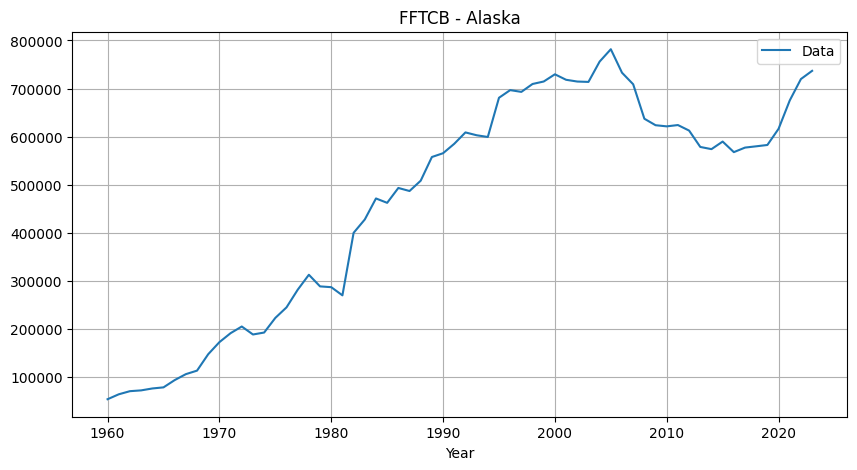

In [79]:
energy_df.toPandas().plot(
    x="Year",
    y="Data",
    figsize=(10,5),
    grid=True,
    title="FFTCB - Alaska"
)

In [80]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=["Year"],
    outputCol="features"
)

ml_df = assembler.transform(energy_df).select("features", "Data")
ml_df.show(5, truncate=False)

+--------+-------+
|features|Data   |
+--------+-------+
|[1960.0]|54633.0|
|[1961.0]|64860.0|
|[1962.0]|71359.0|
|[1963.0]|72995.0|
|[1964.0]|76965.0|
+--------+-------+
only showing top 5 rows


In [81]:
train_data, test_data = ml_df.randomSplit([0.8, 0.2], seed=42)

print("Training:", train_data.count())
print("Testing :", test_data.count())

Training: 49
Testing : 15


In [82]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

lr = LinearRegression(
    featuresCol="features",
    labelCol="Data"
)

lr_model = lr.fit(train_data)

lr_predictions = lr_model.transform(test_data)

evaluator = RegressionEvaluator(
    labelCol="Data",
    predictionCol="prediction",
    metricName="rmse"
)

lr_rmse = evaluator.evaluate(lr_predictions)

print("Linear Regression RMSE:", lr_rmse)

Linear Regression RMSE: 101691.66667148961


In [83]:
from pyspark.ml.regression import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    featuresCol="features",
    labelCol="Data",
    maxDepth=5
)

dt_model = dt.fit(train_data)

dt_predictions = dt_model.transform(test_data)

dt_rmse = evaluator.evaluate(dt_predictions)

print("Decision Tree RMSE:", dt_rmse)

Decision Tree RMSE: 38583.15627350146


In [84]:
from pyspark.ml.regression import RandomForestRegressor

rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="Data",
    numTrees=50,
    maxDepth=5,
    seed=42
)

rf_model = rf.fit(train_data)

rf_predictions = rf_model.transform(test_data)

rf_rmse = evaluator.evaluate(rf_predictions)

print("Random Forest RMSE:", rf_rmse)

Random Forest RMSE: 35649.94646662415


In [85]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "RMSE": [
        lr_rmse,
        dt_rmse,
        rf_rmse
    ]
})

results.sort_values("RMSE")

,Model,RMSE
2,Random Forest,35649.946467
1,Decision Tree,38583.156274
0,Linear Regression,101691.666671


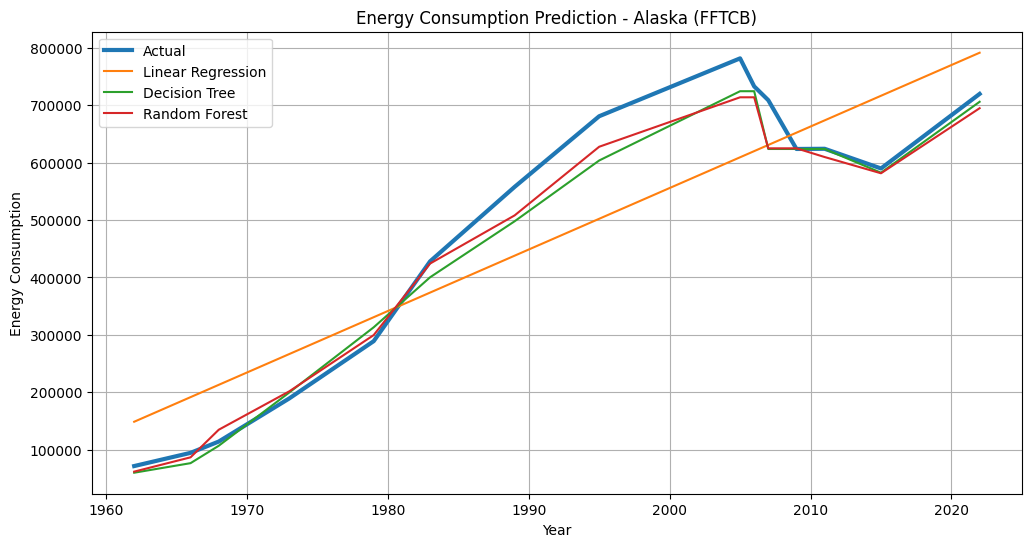

In [88]:
import matplotlib.pyplot as plt
import pandas as pd

actual = test_data.select("Data").toPandas().rename(columns={"Data":"Actual"})
years = test_data.select("features").toPandas()

# Extrair o ano do vetor
years["Year"] = years["features"].apply(lambda x: int(x[0]))

lr = lr_predictions.select("prediction").toPandas().rename(columns={"prediction":"Linear Regression"})
dt = dt_predictions.select("prediction").toPandas().rename(columns={"prediction":"Decision Tree"})
rf = rf_predictions.select("prediction").toPandas().rename(columns={"prediction":"Random Forest"})

comparison = pd.concat([years["Year"], actual, lr, dt, rf], axis=1)
comparison = comparison.sort_values("Year")

plt.figure(figsize=(12,6))

plt.plot(comparison["Year"], comparison["Actual"],
         linewidth=3,
         label="Actual")

plt.plot(comparison["Year"], comparison["Linear Regression"],
         label="Linear Regression")

plt.plot(comparison["Year"], comparison["Decision Tree"],
         label="Decision Tree")

plt.plot(comparison["Year"], comparison["Random Forest"],
         label="Random Forest")

plt.title("Energy Consumption Prediction - Alaska (FFTCB)")
plt.xlabel("Year")
plt.ylabel("Energy Consumption")
plt.grid(True)
plt.legend()

plt.savefig("ml_prediction.png", dpi=300, bbox_inches="tight")
plt.show()


# Conclusion

This project demonstrated an end-to-end machine learning workflow using Apache Spark MLlib to predict historical energy consumption in Alaska based on the FFTCB energy indicator.

Three regression algorithms were evaluated:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

Random Forest achieved the best predictive performance with the lowest RMSE, indicating that ensemble tree-based models are more effective for capturing the non-linear patterns present in historical energy consumption data.

This project also demonstrates practical experience with AWS cloud services, Apache Spark, distributed data processing, machine learning, and data visualization.